<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8; font-family: 'Segoe UI', Tahoma, Arial, sans-serif;">

<h1>&#127828; Fast Food Marketing Campaign &mdash; A/B Testing Analysis</h1>

<h2>&#127919; الهدف</h2>

<p>عندنا سلسلة Fast Food جربت <b>3 Promotions</b> مختلفة على منتج جديد عبر أسواق بأحجام مختلفة (<b>Small, Medium, Large</b>) لمدة 4 أسابيع.</p>

<p><b>الـ Management محتاج يعرف:</b> أنهي Promotion فيهم هي اللي تستاهل نعملها Scale على كل الفروع؟</p>

<p><b>ليه مش بس نبص على الـ Total Sales؟</b> لأن الأرقام الخام ممكن تضللنا! ممكن Promotion تبان إنها الأحسن بس الفرق ده يكون مجرد Random Noise. عشان كده هنعمل <b>A/B Testing</b> &mdash; تحديداً <b>One-Way ANOVA</b> و <b>Tukey HSD</b> &mdash; عشان نتأكد إن الفرق حقيقي مش صدفة.</p>

<h3>الـ Roadmap</h3>
<table style="direction: rtl; text-align: right; width: 100%;">
<tr><th>Step</th><th>إيه اللي هنعمله</th><th>ليه</th></tr>
<tr><td>1</td><td><b>Data Overview</b></td><td>نفهم شكل الـ Dataset والـ Columns والـ Missing Values</td></tr>
<tr><td>2</td><td><b>EDA</b></td><td>نشوف الـ Distributions والـ Weekly Trends</td></tr>
<tr><td>3</td><td><b>Assumption Checks</b></td><td>نشيك على الـ <b>Normal Distribution</b> بالـ <b>Shapiro-Wilk Test</b> والـ <b>Variance</b> بالـ <b>Levene's Test</b></td></tr>
<tr><td>4</td><td><b>One-Way ANOVA</b></td><td>نشوف لو في <b>Statistically Significant</b> Difference بين الـ Means</td></tr>
<tr><td>5</td><td><b>Post-Hoc</b> (<b>Tukey HSD</b>)</td><td>نحدد بالضبط أنهي Pair فيهم الفرق بينهم Significant</td></tr>
<tr><td>6</td><td><b>Executive Recommendation</b></td><td>نحول الـ Stats لقرار Business واضح</td></tr>
</table>

</div>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8; font-family: 'Segoe UI', Tahoma, Arial, sans-serif;">

<h2>1. Data Overview</h2>

<p><b>إيه اللي بنعمله:</b> دلوقتي هنعمل Load للـ Dataset ونبص على أول كام Row عشان نتأكد إن كل حاجة سليمة &mdash; الـ Columns مظبوطة، مفيش <b>Missing Values</b>، والـ Data Types صحيحة.</p>

<p><b>ليه ده مهم للـ Business:</b> لو الـ Data فيها مشاكل، أي Analysis هنعمله بعد كده هيكون مش موثوق. القاعدة: Garbage In = Garbage Out.</p>

<p><b>إزاي نقرا الـ Output:</b> الـ output اللي هيطلع هيورينا عدد الـ Rows والـ Columns، ونتأكد إن <code>isnull().sum()</code> كله أصفار.</p>

</div>

In [ ]:
# Robust loading — works whether you run from 5_Python/ or the root
for path in ['../1_Datasets/dataset_cleaned.csv',
             '../Datasets/dataset_cleaned.csv',
             '../WA_Marketing-Campaign.csv']:
    try:
        df = pd.read_csv(path)
        print(f'Loaded {path}  —  {df.shape[0]} rows × {df.shape[1]} columns')
        break
    except FileNotFoundError:
        continue
else:
    raise FileNotFoundError('Dataset not found.')

df.head()

Loaded ../1_Datasets/dataset_cleaned.csv  —  548 rows × 7 columns


,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


In [ ]:
# Quick health check
print('Missing values:')
print(df.isnull().sum())
print(f'\nData types:\n{df.dtypes}')
print(f'\nDescriptive stats:')
df.describe()

Missing values:
MarketID            0
MarketSize          0
LocationID          0
AgeOfStore          0
Promotion           0
week                0
SalesInThousands    0
dtype: int64

Data types:
MarketID              int64
MarketSize           object
LocationID            int64
AgeOfStore            int64
Promotion             int64
week                  int64
SalesInThousands    float64
dtype: object

Descriptive stats:


,MarketID,LocationID,AgeOfStore,Promotion,week,SalesInThousands
count,548.000000,548.000000,548.000000,548.000000,548.000000,548.000000
mean,5.715328,479.656934,8.503650,2.029197,2.500000,53.466204
std,2.877001,287.973679,6.638345,0.810729,1.119055,16.755216
min,1.000000,1.000000,1.000000,1.000000,1.000000,17.340000
25%,3.000000,216.000000,4.000000,1.000000,1.750000,42.545000
50%,6.000000,504.000000,7.000000,2.000000,2.500000,50.200000
75%,8.000000,708.000000,12.000000,3.000000,3.250000,60.477500
max,10.000000,920.000000,28.000000,3.000000,4.000000,99.650000


<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8; font-family: 'Segoe UI', Tahoma, Arial, sans-serif;">

<h2>2. EDA (Exploratory Data Analysis)</h2>

<h3>2a. Sales Distribution &mdash; Violin Plot</h3>

<p><b>إيه اللي بنعمله:</b> دلوقتي هنعمل <b>Violin Plot</b> لكل Promotion عشان نشوف شكل الـ Distribution بتاع الـ Sales. بنستخدم <b>Violin Plot</b> و <b>KDE</b> عشان نشوف الشكل الحقيقي للـ Distribution &mdash; هل الـ Data متجمعة في مكان معين ولا Spread على بعضها؟ كمان بنحط فوقيه <b>Strip Plot</b> عشان نشوف كل Data Point لوحدها ونكتشف الـ <b>Outliers</b>.</p>

<p><b>ليه ده مهم للـ Business:</b> لو Promotion معينة ليها Distribution "عريض" (يعني الـ Performance بتاعها Volatile جداً بين Branch وبعض)، ده بيقول للـ Management إن الـ Campaign دي مش Consistent حتى لو الـ <b>Mean</b> بتاعها كويس.</p>

<p><b>إزاي نقرا الـ Output:</b> الـ output اللي هيطلع لو تخين في الأعلى = في Sales عالية كتير. لو تخين في الأسفل = في Sales ضعيفة كتير. لو ضيق ومتمركز = Performance ثابت.</p>

</div>

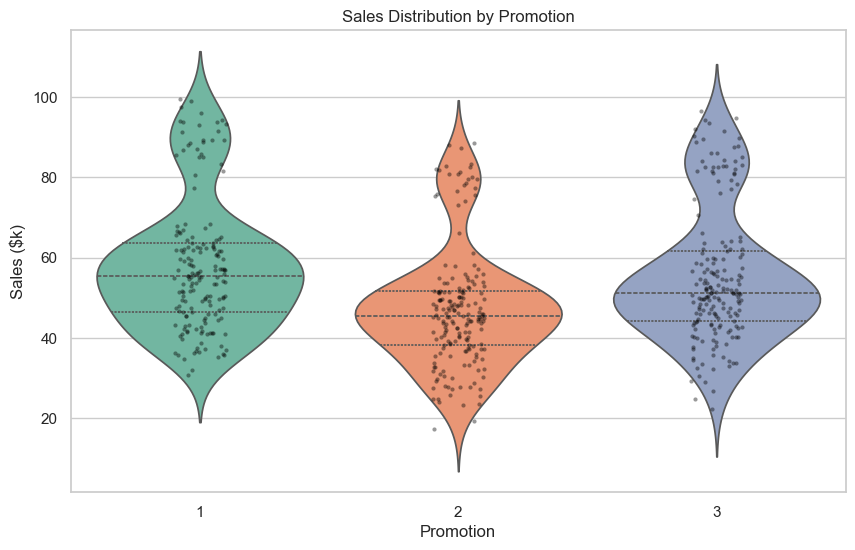

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(x='Promotion', y='SalesInThousands', data=df,
               inner='quartile', palette='Set2', ax=ax)
sns.stripplot(x='Promotion', y='SalesInThousands', data=df,
              color='black', alpha=0.4, size=3, ax=ax)
ax.set_title('Sales Distribution by Promotion')
ax.set_ylabel('Sales ($k)')
plt.show()

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8; font-family: 'Segoe UI', Tahoma, Arial, sans-serif;">

<h3>2b. Weekly Sales Trend</h3>

<p><b>إيه اللي بنعمله:</b> بنرسم <b>Line Chart</b> بيوري الـ <b>Mean</b> بتاع الـ Sales الأسبوعية لكل Promotion على مدار الـ 4 Weeks.</p>

<p><b>ليه ده مهم للـ Business:</b> ممكن Campaign تبدأ قوية جداً في الـ Week 1 بس تنهار في الـ Week 4 &mdash; ظاهرة اسمها <b>Campaign Fatigue</b>. لو ده حصل، مينفعش نعتمد عليها.</p>

<p><b>إزاي نقرا الـ Output:</b> الـ output اللي هيطلع لو الخط بتاعه بينزل بشكل حاد = في <b>Campaign Fatigue</b>. لو الـ Line ثابت أو بيطلع = الـ Campaign مستدامة.</p>

</div>

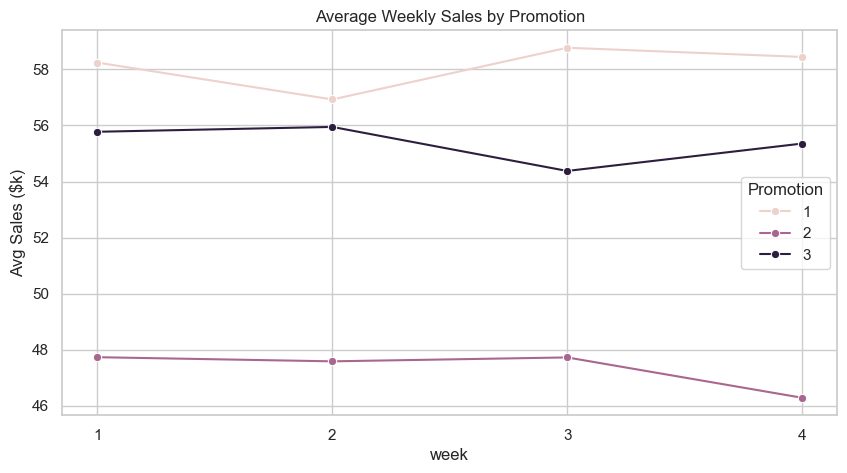

In [ ]:
trend = df.groupby(['week', 'Promotion'], as_index=False)['SalesInThousands'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=trend, x='week', y='SalesInThousands',
             hue='Promotion', marker='o', ax=ax)
ax.set_title('Average Weekly Sales by Promotion')
ax.set_ylabel('Avg Sales ($k)')
ax.set_xticks([1, 2, 3, 4])
plt.show()

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8; font-family: 'Segoe UI', Tahoma, Arial, sans-serif;">

<h3>2c. Summary Statistics</h3>

<p><b>إيه اللي بنعمله:</b> بنعمل جدول فيه الـ <b>Summary Statistics</b> الأساسية لكل Promotion: الـ <b>Sample Size</b> (N)، الـ <b>Mean</b>، الـ <b>Median</b>، الـ <b>Standard Deviation</b>.</p>

<p><b>ليه ده مهم للـ Business:</b> الـ <b>Mean</b> بيقولك الـ Performance العام. الـ <b>Standard Deviation</b> بيقولك الـ Performance ده Consistent ولا لأ.</p>

<p><b>إزاي نقرا الـ Output:</b> الـ output اللي هيطلع هنقارن فيه الـ <b>Mean</b> بين الـ 3 Promotions. ده أول Indicator لينا.</p>

</div>

In [ ]:
summary = (
    df.groupby('Promotion')['SalesInThousands']
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .round(2)
)
summary.columns = ['N', 'Mean', 'Median', 'Std', 'Min', 'Max']
summary

,N,Mean,Median,Std,Min,Max
Promotion,,,,,,
1,172,58.10,55.39,16.55,30.81,99.65
2,188,47.33,45.39,15.11,17.34,88.64
3,188,55.36,51.16,16.77,22.18,96.48


<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8; font-family: 'Segoe UI', Tahoma, Arial, sans-serif;">

<h2>3. Testing ANOVA Assumptions</h2>

<p>عشان نعمل <b>ANOVA</b> لازم نشيك على الـ <b>Normal Distribution</b> والـ <b>Variance</b>.</p>

<h3>3a. Normality Check &mdash; Shapiro-Wilk Test</h3>

<p><b>إيه اللي بنعمله:</b> دلوقتي هنعمل <b>Shapiro-Wilk Test</b> عشان نشيك على الـ <b>Normal Distribution</b>.</p>

<ul>
<li><b>Null Hypothesis (H0):</b> الـ Data بتتبع <b>Normal Distribution</b>.</li>
<li><b>Alternative Hypothesis (H1):</b> الـ Data مش بتتبع <b>Normal Distribution</b>.</li>
</ul>

<p><b>ليه ده مهم للـ Business:</b> لو الـ Assumptions اتخرقت، نتيجة الـ <b>ANOVA</b> هتكون غلط.</p>

<p><b>إزاي نقرا الـ Output:</b> لو الـ <b>P-value</b> أقل من 0.05 يبقى الـ Data مش Normal. لو أكبر من 0.05 يبقى الـ Distribution طبيعي (مقدرناش نرفض الـ <b>H0</b>). كمان هنرسم <b>Q-Q Plot</b> للتأكيد.</p>

</div>

In [ ]:
for promo in sorted(df['Promotion'].unique()):
    sales = df.loc[df['Promotion'] == promo, 'SalesInThousands']
    stat, p = stats.shapiro(sales)
    verdict = '✅ Normal' if p > 0.05 else '⚠️ Not normal'
    print(f'Promo {promo}  |  W={stat:.4f}  p={p:.4e}  →  {verdict}')

Promo 1  |  W=0.9153  p=1.9773e-08  →  ⚠️ Not normal
Promo 2  |  W=0.9145  p=5.4571e-09  →  ⚠️ Not normal
Promo 3  |  W=0.9208  p=1.4995e-08  →  ⚠️ Not normal


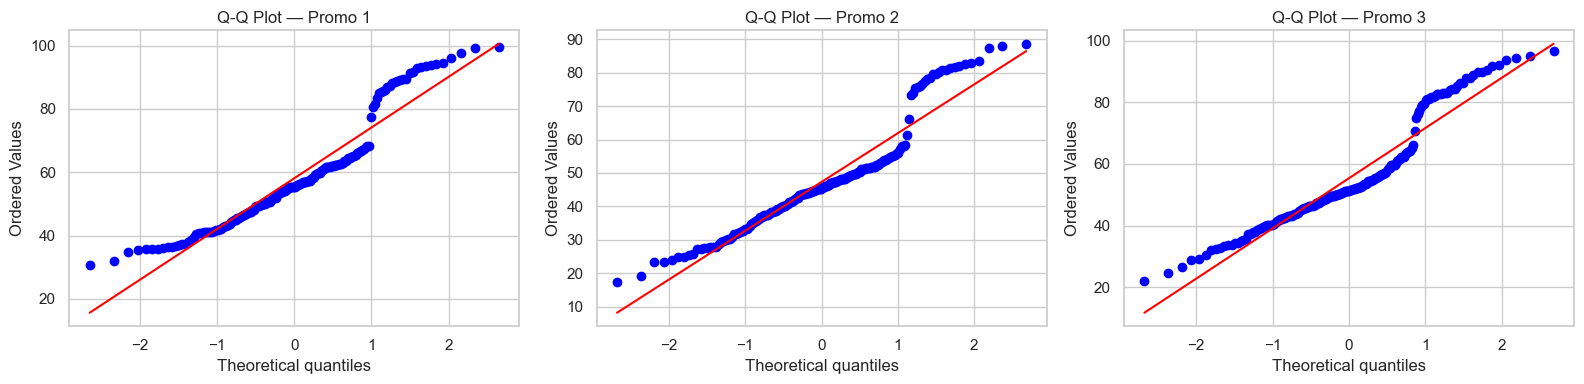

In [ ]:
# Visual check with Q-Q plots
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, promo in enumerate([1, 2, 3]):
    stats.probplot(df.loc[df['Promotion'] == promo, 'SalesInThousands'],
                   dist='norm', plot=axes[i])
    axes[i].set_title(f'Q-Q Plot — Promo {promo}')
plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8; font-family: 'Segoe UI', Tahoma, Arial, sans-serif;">

<h3>3b. Equal Variance Check &mdash; Levene's Test</h3>

<p><b>إيه اللي بنعمله:</b> دلوقتي هنعمل <b>Levene's Test</b> عشان نتأكد إن الـ <b>Variance</b> متساوي.</p>

<ul>
<li><b>Null Hypothesis (H0):</b> كل الـ Groups ليها نفس الـ <b>Variance</b>.</li>
<li><b>Alternative Hypothesis (H1):</b> على الأقل Group واحدة الـ <b>Variance</b> بتاعها مختلف.</li>
</ul>

<p><b>ليه ده مهم للـ Business:</b> لو الـ <b>Variance</b> مش متساوي، الـ <b>One-Way ANOVA</b> هيدي نتايج غلط.</p>

<p><b>إزاي نقرا الـ Output:</b> لو الـ <b>P-value</b> أقل من 0.05 يبقى الـ <b>Variance</b> مش متساوي.</p>

</div>

In [ ]:
groups = [df.loc[df['Promotion'] == p, 'SalesInThousands'] for p in [1, 2, 3]]
stat, p = stats.levene(*groups)
print(f"Levene's test  |  Statistic={stat:.4f}  p={p:.4e}")
if p > 0.05:
    print('✅ Variances are equal — standard ANOVA is fine.')
else:
    print('⚠️ Variances differ — consider Welch ANOVA.')

Levene's test  |  Statistic=1.2697  p=2.8175e-01
✅ Variances are equal — standard ANOVA is fine.


<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8; font-family: 'Segoe UI', Tahoma, Arial, sans-serif;">

<h2>4. One-Way ANOVA</h2>

<p><b>إيه اللي بنعمله:</b> دلوقتي هنعمل <b>One-Way ANOVA</b> عشان نشوف لو الـ <b>Mean</b> مختلف فعلاً ولا ده مجرد صدفة.</p>

<ul>
<li><b>Null Hypothesis (H0):</b> الـ 3 Promotions ليهم نفس الـ <b>Mean</b>.</li>
<li><b>Alternative Hypothesis (H1):</b> على الأقل Promotion واحد الـ <b>Mean</b> بتاعه مختلف.</li>
</ul>

<p><b>ليه ده مهم للـ Business:</b> ده الـ Test اللي بيحسم الموضوع. الـ Management محتاج يعرف إذا كان الفرق <b>Statistically Significant</b>.</p>

<p><b>إزاي نقرا الـ Output:</b> الـ output اللي هيطلع هيورينا الـ <b>F-statistic</b> والـ <b>P-value</b>. لو الـ <b>P-value</b> أقل من 0.05 يبقى هنرفض الـ <b>H0</b> وفي <b>Statistically Significant</b> Difference.</p>

</div>

In [ ]:
f_stat, p_val = stats.f_oneway(*groups)
print(f'F-statistic: {f_stat:.4f}')
print(f'P-value:     {p_val:.4e}')
print()
if p_val < 0.05:
    print('🟢 Reject H₀ — at least one promotion differs significantly.')
else:
    print('🔴 Fail to reject H₀ — no significant difference detected.')

F-statistic: 21.9535
P-value:     6.7658e-10

🟢 Reject H₀ — at least one promotion differs significantly.


<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8; font-family: 'Segoe UI', Tahoma, Arial, sans-serif;">

<h2>5. Post-Hoc Analysis &mdash; Tukey HSD</h2>

<p><b>إيه اللي بنعمله:</b> الـ <b>One-Way ANOVA</b> قالنا إن في فرق، بس مقالناش مين أحسن من مين. الـ <b>Tukey HSD</b> بيقارن كل pair ببعضه.</p>

<p><b>ليه ده مهم للـ Business:</b> الـ Management محتاج يعرف أنهي Promotion نكمل بيها وأنهي نوقفها بناءً على الـ <b>Post-Hoc</b> Analysis.</p>

<p><b>إزاي نقرا الـ Output:</b> الـ output اللي هيطلع هيورينا عمود reject. لو True يبقى الفرق <b>Statistically Significant</b>. لو False يبقى <b>Statistically Insignificant</b>.</p>

</div>

In [ ]:
tukey = pairwise_tukeyhsd(
    endog=df['SalesInThousands'],
    groups=df['Promotion'],
    alpha=0.05,
)
print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     1      2 -10.7696    0.0 -14.7738 -6.7654   True
     1      3  -2.7345 0.2444  -6.7388  1.2697  False
     2      3   8.0351    0.0   4.1208 11.9493   True
-----------------------------------------------------


<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8; font-family: 'Segoe UI', Tahoma, Arial, sans-serif;">

<h2>6. &#x1F680; Executive Recommendation</h2>

<h3>Results Summary</h3>
<table style="direction: rtl; text-align: right; width: 100%; border-collapse: collapse;">
<tr style="background: #f0f0f0;"><th style="padding: 8px;">Comparison</th><th style="padding: 8px;">Significant?</th><th style="padding: 8px;">Insight</th></tr>
<tr><td style="padding: 8px;">Promo 1 vs Promo 2</td><td style="padding: 8px; text-align: center;">&#x2705; Yes</td><td style="padding: 8px;">Promotion 1 أحسن بكتير</td></tr>
<tr><td style="padding: 8px;">Promo 3 vs Promo 2</td><td style="padding: 8px; text-align: center;">&#x2705; Yes</td><td style="padding: 8px;">Promotion 3 أحسن بكتير</td></tr>
<tr><td style="padding: 8px;">Promo 1 vs Promo 3</td><td style="padding: 8px; text-align: center;">&#x274C; No</td><td style="padding: 8px;">الاتنين <b>Statistically Insignificant</b> (مفيش فرق)</td></tr>
</table>

<h3>&#x1F4BC; Action Plan للـ Management</h3>

<p><b>1. الخلاصة: نوقف الـ Promotion 2 فوراً.</b><br>ده بيخسرنا. الـ Data بتأكد بشكل <b>Statistically Significant</b> إنه بيجيب Sales أقل.</p>

<p><b>2. الاختيار بين Promotion 1 و Promotion 3:</b><br>الاتنين دول <b>Statistically Insignificant</b> من بعض. الـ Management محتاج يعرف الـ Secondary Factors زي:</p>
<ul>
<li>Cost؟</li>
<li>Brand Strategy؟</li>
<li>Market Segment؟</li>
</ul>

<p><b>الخلاصة:</b> الـ Data بتقول إن Promotion 1 و 3 كلاهما Winner.</p>

</div>